# Word Cloud using CSV (En)

Data: Movie Reviews (`./data/movie_reviews_en.csv`)

### 1. Load Data

In [69]:
import pandas as pd

df = pd.read_csv('./data/movie_reviews_en.csv', sep=',')
df.head()

,text,label
0,If you havent seen this movie than you need to...,1
1,but Cinderella gets my vote not only for the w...,0
2,This movie is pretty cheesy but I do give it c...,1
3,I have not seen a Van Damme flick for a while ...,1
4,This is a sleeper It defines Nicholas Cage The...,1


In [70]:
df.shape

(40000, 2)

In [71]:
df['label'].value_counts() #.to_frame()

label
0    20049
1    19951
Name: count, dtype: int64

### 2. Text Preprocessing

In [72]:
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def get_words(text, custom_stopwords=None):
    text = text.lower()
    
    # tokenization
    words = word_tokenize(text)

    # pos tagging
    tagged = pos_tag(words)
    words = [w for w, pos in tagged if pos[0] in ['N', 'J', 'V']] # keep only nouns and adjectives

    # remove stopwords
    stop_words_list = stopwords.words('english')
    if custom_stopwords is not None:
        stop_words_list += custom_stopwords  # Add any custom stopwords if needed
    words = [w for w in words if not w in stop_words_list]

    # converts a word to its base or dictionary form
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words] # lemmatization

    return words

In [73]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

def draw_wordcloud(words, title=None):
    word_frequencies_dict = Counter(words)
    wordcloud = WordCloud(width=800, height=400, background_color='white')
    wordcloud = wordcloud.generate_from_frequencies(word_frequencies_dict)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [74]:
custom_stopwords = ['movie', 'film', 'one', 'character', 'story', 'people', 'scene', 'way', 'thing', 'time',]
df['words'] = df['text'].apply(
    lambda x: get_words(x, custom_stopwords=custom_stopwords))

### 3. Draw Wordclouds

#### 3-1. All reviews

length of flat_list 3924621


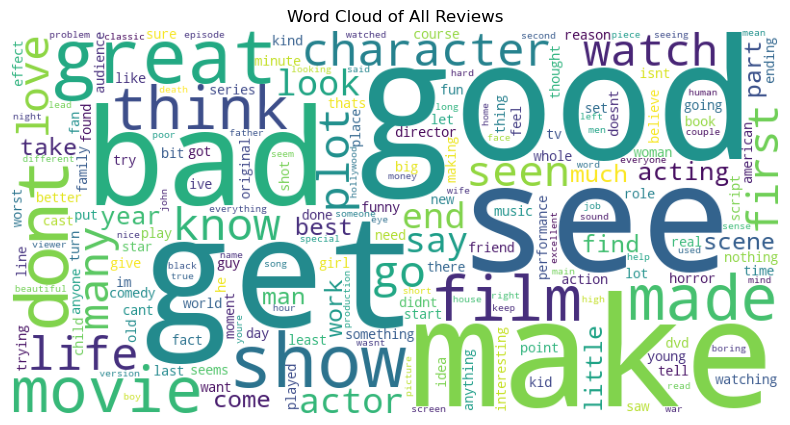

In [75]:
import itertools

def flatten_list(list_of_lists):
    return list(itertools.chain.from_iterable(list_of_lists))

# get words for all reviews
list_of_lists = df['words'].tolist()
flat_list = flatten_list(list_of_lists)
print('length of flat_list', len(flat_list))

# draw word cloud for all reviews
draw_wordcloud(flat_list, title='Word Cloud of All Reviews')

#### 3-2. Positive/Negative Reviews


In [76]:
# filter reviews by label
pos_reviews_words = df.loc[df['label']==1, 'words']
neg_reviews_words = df.loc[df['label']==0, 'words']

print('Number of positive reviews:', len(pos_reviews_words))
print('Number of negative reviews:', len(neg_reviews_words))

Number of positive reviews: 19951
Number of negative reviews: 20049


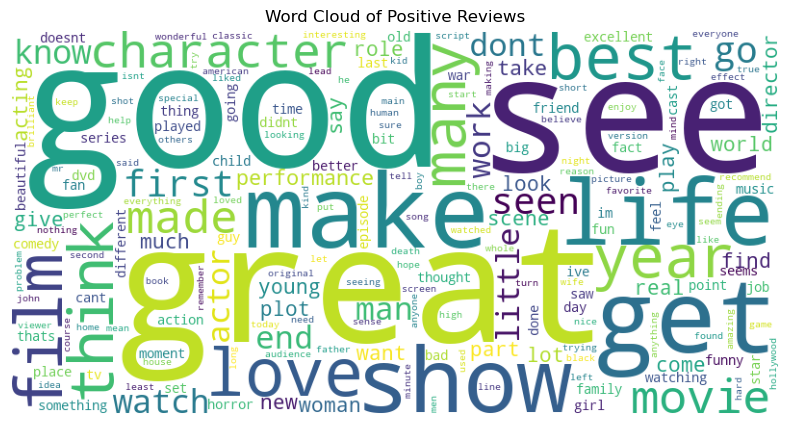

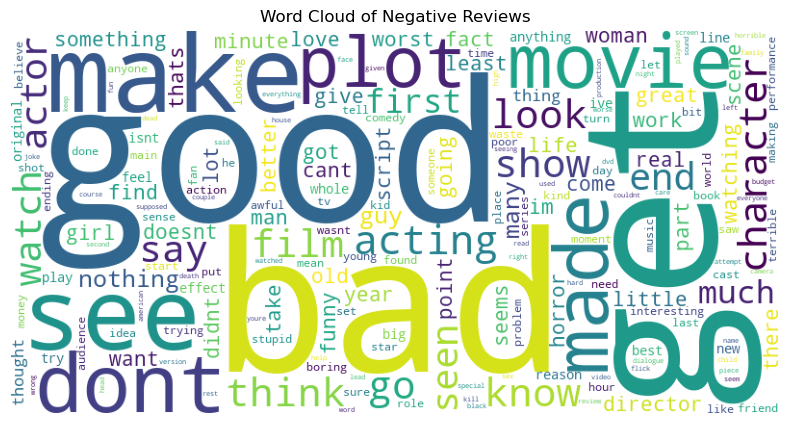

In [77]:
# positive reviews word cloud
word_list_pos = flatten_list(pos_reviews_words)
draw_wordcloud(word_list_pos, title='Word Cloud of Positive Reviews')

# negative reviews word cloud
word_list_neg = flatten_list(neg_reviews_words)
draw_wordcloud(word_list_neg, title='Word Cloud of Negative Reviews')

#### Drill-down: Let's try to understand the context of keywords!

In [78]:
# Q. Find and display some negative reviews that contain the word "good"
df.loc[(df['label']==0) & (df['words'].apply(lambda x: 'good' in x)), ['text']]

,text
1,but Cinderella gets my vote not only for the w...
5,This movie has no heart and no soul its an att...
14,John Scott John Wayne and partner Kansas Charl...
18,This is the kind of movie that BEGS to be show...
20,OK I for one thought the trailer was quite goo...
...,...
39986,i was given the book version of Kazaam for my ...
39990,This movie is silly and very short of being a ...
39991,I have a 5 minute rule sometimes Ill leave lew...
39994,This movie is one of the worst movie i have ev...


In [79]:
# get the text of the review having index 1
df.loc[29902].text

'Youve got to be kidding This movie sucked for the scifi fans I would only recommend watching this only if you think Armageddon was good'